# Regresión lineal: implementación en Keras

## 1. Configuración Google Drive

In [1]:
ruta = 'https://raw.githubusercontent.com/cagomezv/AP_USA/refs/heads/main/Semana_1/Data/dataset_LR.csv'

## 2. Lectura y visualización del set de datos

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import SGD
import tensorflow as tf

np.random.seed(25)
tf.random.set_seed(25)

In [13]:
data = pd.read_csv(ruta)

In [14]:
data.head()

,Area,Precio
0,152.272727,65928.86015
1,102.272727,44477.41849
2,222.727273,95848.62198
3,79.545455,44964.89827
4,86.363636,34367.39122


In [15]:
data.shape

(100, 2)

In [16]:
x = data['Area'].values
y = data['Precio'].values

Text(0, 0.5, 'y (precio (en U$)')

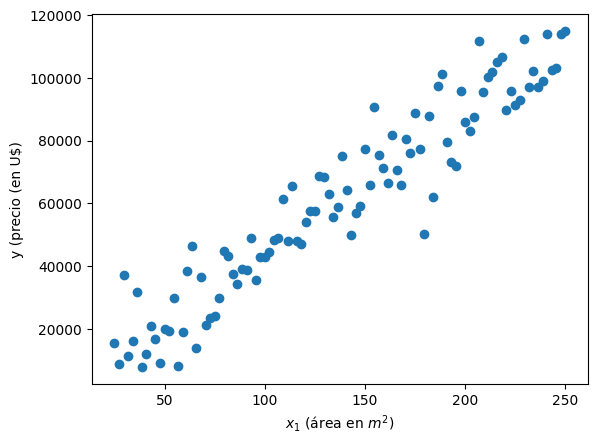

In [17]:
plt.scatter(x,y)
plt.xlabel('$x_1$ (área en $m^2$)')
plt.ylabel('y (precio (en U$)')

## 3. Construir el modelo lineal en Keras

In [18]:
# Contenedor vacío
modelo = Sequential()

In [19]:
# Comenzar a llenar el modelo ('add')

modelo.add(Input(shape=(1,)))
modelo.add(Dense(1, activation='linear'))

In [20]:
# Información del modelo y = wx + b
modelo.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

## 4. Optimizador (Gradiente Descendente Estocástico) y pérdida

In [21]:
lr = 0.00001
optimizador = SGD(learning_rate=lr)
modelo.compile(optimizer=optimizador, loss='mse')

## 5. Entrenamiento y predicción

In [22]:
n_epochs = 20
s_minibatches = 10 # Probar con diferentes batch_sizes
historia = modelo.fit(x,y,epochs=n_epochs,batch_size=s_minibatches,verbose=1)

Epoch 1/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 795495040.0000   
Epoch 2/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 92798344.0000 
Epoch 3/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 92734176.0000 
Epoch 4/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 92734064.0000 
Epoch 5/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 92734072.0000 
Epoch 6/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 92734072.0000 
Epoch 7/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 92734064.0000 
Epoch 8/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 92734056.0000 
Epoch 9/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 92734048.0000 
Epoch 10/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 92734056.0000 
Epoch 11/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 92734032.0000 
Epoch 12/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 92734032.0000 
Epoch 13/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 92734032.0000 
Epoch 14/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5m

### 5.1 Comportamiento del error

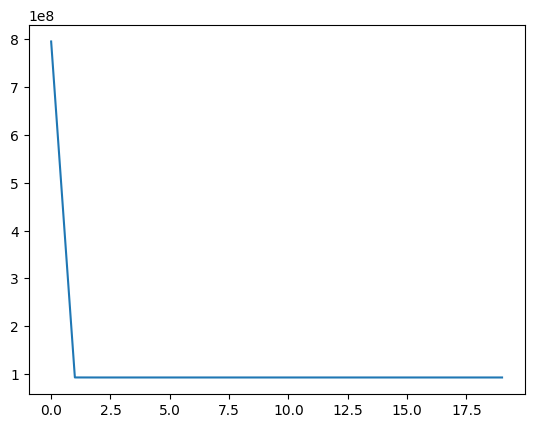

In [24]:
plt.plot(historia.history['loss'])
plt.show()

### 5.2 Predicción

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 


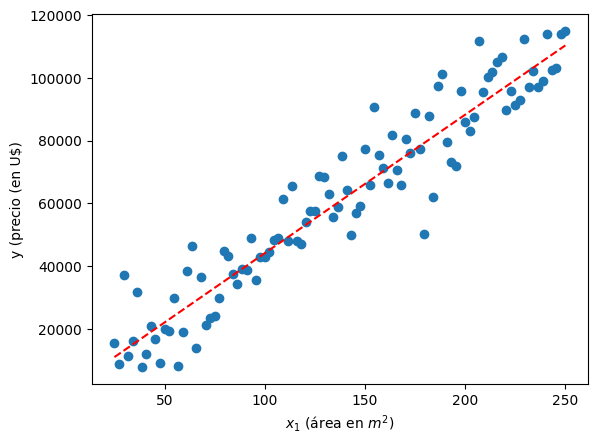

In [26]:
# Dibujar recta resultante
x_pred = np.linspace(x.min(),x.max(),x.shape[0])
y_pred = modelo.predict(x_pred)

plt.scatter(x,y)
plt.plot(x_pred,y_pred,'r--')
plt.xlabel('$x_1$ (área en $m^2$)')
plt.ylabel('y (precio (en U$)')
plt.show()